# Railroad Pier-Cap Strut-and-Tie Design

This production-oriented notebook generates and checks a longitudinal two-dimensional STM for a pile-supported concrete railroad bridge cap. It uses one common physical candidate structure for all supplied combinations and automates conservative strut, tie, nodal-zone, anchorage, and section-level reinforcement checks.

## Important status

- The included load factors are demonstration values, **not AREMA design combinations**.
- Enter project-specific combinations from the governing AREMA edition.
- Positive member force denotes tension; negative force denotes compression.
- AREMA 2025 Article 2.30.2b resistance factors, Article 2.42 nodal factors, and the supplied reinforcement provisions are implemented.
- Final three-dimensional bar positioning, drawings, foundation design, and project load generation are outside this two-dimensional analysis.
- Arbitrary polygonal cross-section and local ledge analysis are outside this notebook's scope.

In [1]:
from pathlib import Path
import sys

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'stm_solver').exists() and (path / 'notebooks' / 'pier_cap_design.ipynb').exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from stm_solver.design_checks import (
    apply_conservative_strut_policy, arema_2025_nodal_stress_factors, arema_2025_stm_resistance_factors, calculate_strut_width_profiles,
    REBAR_TABLE, calculate_standard_hook_development,
    calculate_tension_development_length,
    calculate_tie_end_anchorage_geometry, check_reinforcement_cage_congestion,
    check_strut, check_interior_nodal_zone_faces, classify_strut_shapes, design_orthogonal_crack_control_grid,
    check_provided_crack_control_grid, check_provided_tie_bar_layout,
    design_tie_bar_layout, extended_strut_tie_critical_section,
    check_subdivided_nodal_zone_faces, check_tie,
    construct_continuous_tie_nodal_zone, construct_memberwise_external_nodal_zones,
    construct_single_strut_external_nodal_zone,
)
from stm_solver.ground_structure import (
    find_member_crossings, optimize_frame_boundary_load_cases,
    optimize_pier_cap_load_cases,
)
from stm_solver.pier_cap import (
    FoundationSupport, LoadCombination, LoadComponent, LoadPointForce,
    PierCapGeometry, PierCapLoadSet, PierCapModel,
)
from stm_solver.tables import (
    conservative_strut_design_records, crack_control_records,
    design_check_records, export_csv_tables, export_excel_tables, export_json_tables, ground_structure_records, multi_load_ground_structure_records, nodal_geometry_records, pier_cap_analysis_records,
    strut_shape_records, strut_width_records, tie_anchorage_records,
    reinforcement_cage_review_records,
    standard_hook_records, tension_development_records,
    tie_bar_layout_records,
    records_to_dataframes,
)
from stm_solver.reporting import (
    build_pier_cap_calculation_report, build_pier_cap_html_report,
    write_calculation_report, write_html_report,
)
from stm_solver.versioning import build_calculation_metadata

## 1. User inputs

Edit only this section for a new demonstration model. Keep all coordinates in inches and forces in kips. Load-point IDs must retain the same coordinates in every component in which they appear.

In [2]:
project = {
    'name': 'DEMONSTRATION - Railroad Pier Cap',
    'designer': 'MRC',
    'date': '09/08/2026',
    'revision': '0',
    'governing_standard': 'AREMA edition and chapter to be supplied',
    'units': {'length': 'in', 'force': 'kip', 'stress': 'ksi'},
}

cap = {
    'length': 201.0,
    'depth': 30.0,
    'width': 42.0,
    'top_tie_y': 27.0,
    'bottom_tie_y': 3.0,
}

materials = {
    'fc_ksi': 5.0,
    'fy_ksi': 60.0,
}

# Visible, editable detailing defaults. These are reported with the results.
detailing = {
    'clear_cover': 2.0,
    'maximum_aggregate_size': 0.75,
    'lightweight_concrete': False,
    'epoxy_coated_reinforcement': False,
    'minimum_longitudinal_bar_size': 5,
    'maximum_longitudinal_bar_size': 5,
    'allow_standard_hooks': True,
    'credit_excess_reinforcement_for_development': False,
    # Opt in to a reviewable, force-proportioned tributary for each strut
    # when more than one compression strut enters a bearing/support face.
    'allow_automatic_external_node_subdivision': True,
}

# Optional existing/preferred reinforcement. Leave as None for automatic design.
# Crack-control reinforcement is entered by physical bar size, number of
# legs crossing the section at each interval, and spacing. Steel area is derived.
# provided_reinforcement = None
provided_reinforcement = {
    'top': {'bar_count': 8, 'bar_size': 8, 'layers': 1},
    'bottom': {'bar_count': 8, 'bar_size': 8, 'layers': 1},
    'crack_control': {
        'vertical': {'bar_size': 5, 'legs': 4, 'spacing': 6.0},
        'horizontal': {'bar_size': 5, 'legs': 2, 'spacing': 6.0},
    },
}

# Verified AREMA 2025 Article 2.30.2b STM resistance factors.
arema_phi = arema_2025_stm_resistance_factors()
code_profile = {
    'name': 'AREMA 2025 Chapter 8 Articles 2.30.2b and 2.42 + supplied reinforcement sections',
    'phi_tie': arema_phi['reinforced_concrete_tension'],
    'phi_concrete': arema_phi['compression'],
    'resistance_factor_status': 'VERIFIED - AREMA 2025 Article 2.30.2b',
}

output_options = {
    'write_files': True,
    'directory': repo_root / 'output' / 'pier_cap',
    'write_excel': False,
}

piles = [
    {'id': 'P1', 'x': 36.0, 'y': 0.0, 'type': 'pin', 'face_width': 18.0},
    {'id': 'P2', 'x': 96.0, 'y': 0.0, 'type': 'roller', 'face_width': 18.0},
    {'id': 'P3', 'x': 156.0, 'y': 0.0, 'type': 'pin', 'face_width': 18.0},
]

# Unfactored or separately factored load components. The values below are
# demonstrations only and must not be interpreted as AREMA requirements.
load_components = {
    'DEAD': [
        {'id': 'B1', 'x': 6.5, 'y': 30.0, 'Px': 0.0, 'Py': -39.789},
        {'id': 'B2', 'x': 57.5, 'y': 30.0, 'Px': 0.0, 'Py': -36.714},
        {'id': 'B3', 'x': 72.0, 'y': 30.0, 'Px': 0.0, 'Py': -36.714},
        {'id': 'B4', 'x': 120.0, 'y': 30.0, 'Px': 0.0, 'Py': -36.714},
        {'id': 'B5', 'x': 134.5, 'y': 30.0, 'Px': 0.0, 'Py': -36.714},
        {'id': 'B6', 'x': 185.5, 'y': 30.0, 'Px': 0.0, 'Py': -39.789},
    ],
    'LIVE_DEMO': [
        {'id': 'B1', 'x': 6.5, 'y': 30.0, 'Px': 0.0, 'Py': -16.566},
        {'id': 'B2', 'x': 57.5, 'y': 30.0, 'Px': 0.0, 'Py': -79.009},
        {'id': 'B3', 'x': 72.0, 'y': 30.0, 'Px': 0.0, 'Py': -85.062},
        {'id': 'B4', 'x': 120.0, 'y': 30.0, 'Px': 0.0, 'Py': -85.062},
        {'id': 'B5', 'x': 134.5, 'y': 30.0, 'Px': 0.0, 'Py': -36.000},
        {'id': 'B6', 'x': 185.5, 'y': 30.0, 'Px': 0.0, 'Py': -0.001},
    ],
}

load_face_widths = {load_id: 12.0 for load_id in ('B1', 'B2', 'B3', 'B4', 'B5', 'B6')}

# Replace these demonstration factors with reviewed project-specific AREMA combinations.
load_combinations = {
    'VERTICAL': {'DEAD': 1.0, 'LIVE_DEMO': 1.0},
    'DEAD_ONLY': {'DEAD': 1.0},
}

generation = {
    'min_angle': 25.0,
    'max_angle': 75.0,
}

# Analysis mode. The default pile-supported workflow is unchanged. Use
# 'frame_boundary' only when reviewed adjoining-region interface forces are
# available; see frame_model below for the required input schema.
analysis_mode = 'pier_cap'
frame_model = None


## 2. Validate and assemble load combinations

This gate stops the analysis for invalid geometry, unknown components, inconsistent load-point coordinates, or loads and piles outside the longitudinal cap envelope.

In [3]:
run_design_checks = analysis_mode == 'pier_cap'
if run_design_checks:
    geometry = PierCapGeometry(
        depth=cap['depth'], top_tie_y=cap['top_tie_y'],
        bottom_tie_y=cap['bottom_tie_y'], length=cap['length'], width=cap['width'],
    )
    supports = tuple(
        FoundationSupport(
            pile['id'], pile['x'], pile['y'], pile['face_width'],
            restraint=pile['type'], foundation_type=pile.get('foundation_type', 'pile'),
        )
        for pile in piles
    )
    components = tuple(
        LoadComponent(name, tuple(
            LoadPointForce(
                load['id'], load['x'], load['y'], load['Py'], px=load.get('Px', 0.0),
            )
            for load in loads
        ))
        for name, loads in load_components.items()
    )
    combinations = tuple(LoadCombination(name, factors) for name, factors in load_combinations.items())
    load_set = PierCapLoadSet(components, combinations, load_face_widths)
    load_set.validate_envelope(geometry)
    assembled_loads = load_set.assemble_all()
    models = {name: PierCapModel(geometry, loads, supports, metadata=project) for name, loads in assembled_loads.items()}
    combination_loads = {name: [load.to_solver_dict() for load in loads] for name, loads in assembled_loads.items()}
    piles = [support.to_solver_dict() for support in supports]
    print(f"Validated {len(supports)} supports, {len(components)} load components, and {len(models)} combinations.")
else:
    if frame_model is None:
        raise ValueError("frame_model is required when analysis_mode='frame_boundary'")
    frame_nodes = frame_model['top_nodes'] + frame_model['lower_nodes'] + frame_model['boundary_nodes']
    frame_node_lookup = {node['id']: node for node in frame_nodes}
    combination_loads = {
        name: [dict(load, id=load['node'], x=frame_node_lookup[load['node']]['x'], y=frame_node_lookup[load['node']]['y']) for load in loads]
        for name, loads in frame_model['load_cases'].items()
    }
    piles = [dict(node, type='fixed', face_width=0.0) for node in frame_model['boundary_nodes']]
    models = {}
    print(f"Validated {len(frame_model['boundary_nodes'])} frame-boundary nodes and {len(combination_loads)} load case(s).")
for name, loads in combination_loads.items():
    resultant = np.sum([[load.get('Px', 0.0), load.get('Py', 0.0)] for load in loads], axis=0)
    print(f"  {name:<30} Fx={resultant[0]:9.1f} kip  Fy={resultant[1]:9.1f} kip")


Validated 3 supports, 2 load components, and 2 combinations.
  VERTICAL                       Fx=      0.0 kip  Fy=   -528.1 kip
  DEAD_ONLY                      Fx=      0.0 kip  Fy=   -226.4 kip


## 3. Generate and solve one common STM ground structure

One candidate structure is generated from the common physical load/support locations. Candidates unused by every combination are pruned, every case is re-solved for equilibrium, and force reversals are reported explicitly.

In [4]:
if run_design_checks:
    common_analysis = optimize_pier_cap_load_cases(
        combination_loads, piles,
        top_tie_y=cap['top_tie_y'], bottom_tie_y=cap['bottom_tie_y'],
        min_angle=generation['min_angle'], max_angle=generation['max_angle'],
    )
else:
    common_analysis = optimize_frame_boundary_load_cases(
        frame_model['top_nodes'], frame_model['lower_nodes'], frame_model['boundary_nodes'],
        frame_model['load_cases'],
        boundary_member_targets=frame_model.get('boundary_member_targets'),
        target_relative_tolerance=frame_model.get('target_relative_tolerance', 0.0),
        min_angle=generation['min_angle'], max_angle=generation['max_angle'],
        force_tolerance=generation.get('force_tolerance', 1e-6),
    )
results = common_analysis.case_results

summary_records = []
for name, result in results.items():
    summary_records.append({
        'combination': name, 'candidate_count': result.candidate_count,
        'selected_count': len(result.member_forces),
        'equilibrium_residual_kip': result.equilibrium_residual,
    })
    assert result.equilibrium_residual < 1e-7
result_tables = {name: records_to_dataframes(ground_structure_records(result)) for name, result in results.items()}
summary_table = records_to_dataframes({'summary': summary_records})['summary']
common_tables = records_to_dataframes(multi_load_ground_structure_records(common_analysis))
display(summary_table)
print(f'Common candidates: {common_analysis.initial_candidate_count} generated, {len(common_analysis.members)} retained after {common_analysis.pruning_iterations} pruning iteration(s).')
if common_analysis.force_reversals:
    display(common_tables['force_reversals'])
else:
    print('Force-reversal check: PASS - no common member changes between tension and compression.')


,combination,candidate_count,selected_count,equilibrium_residual_kip
0,VERTICAL,32,30,2.309264e-14
1,DEAD_ONLY,32,25,7.105427e-15


Common candidates: 64 generated, 32 retained after 1 pruning iteration(s).


,candidate_id,node_i,node_j,tension_combinations,compression_combinations,maximum_tension,maximum_compression
0,13,10,11,"(DEAD_ONLY,)","(VERTICAL,)",16.017688,-16.231083
1,26,12,13,"(DEAD_ONLY,)","(VERTICAL,)",16.017688,-16.231083


In [5]:
crossing_failures = {}
for name, result in results.items():
    crossings = find_member_crossings(
        result.truss_model.nodes, result.truss_model.members,
    )
    if crossings:
        crossing_failures[name] = crossings
if crossing_failures:
    details = '; '.join(
        f'{name}: member-index pairs {pairs}'
        for name, pairs in crossing_failures.items()
    )
    raise RuntimeError(
        'Topology review failed: unintended non-nodal member crossings were found. '
        + details
    )
print('Crossing check: PASS - no non-nodal selected-member intersections.')

Crossing check: PASS - no non-nodal selected-member intersections.


In [6]:
if run_design_checks:
    print(f"{'combination':<30} {'support':<10} {'Rx (kip)':>12} {'Ry (kip)':>12}")
    print('-' * 68)
    inactive_supports = []
    for name, result in results.items():
        for pile_index, pile in enumerate(piles):
            node = result.truss_model.support_node_ids[pile_index]
            rx = result.reactions.get(2 * node, 0.0)
            ry = result.reactions.get(2 * node + 1, 0.0)
            print(f"{name:<30} {pile['id']:<10} {rx:12.1f} {ry:12.1f}")
            if abs(rx) < 1e-6 and abs(ry) < 1e-6:
                inactive_supports.append((name, pile['id']))
else:
    print(f"{'combination':<30} {'boundary':<10} {'Rx (kip)':>12} {'Ry (kip)':>12}")
    print('-' * 68)
    offset = len(frame_model['top_nodes']) + len(frame_model['lower_nodes'])
    for name, result in results.items():
        for boundary_index, boundary in enumerate(frame_model['boundary_nodes']):
            node = offset + boundary_index
            print(f"{name:<30} {boundary['id']:<10} {result.reactions.get(2*node, 0.0):12.1f} {result.reactions.get(2*node+1, 0.0):12.1f}")


combination                    support        Rx (kip)     Ry (kip)
--------------------------------------------------------------------
VERTICAL                       P1                 -0.0        164.8
VERTICAL                       P2                  0.0        250.8
VERTICAL                       P3                 -0.0        112.5
DEAD_ONLY                      P1                 -0.0         87.2
DEAD_ONLY                      P2                  0.0         52.1
DEAD_ONLY                      P3                 -0.0         87.2


## 4. Topology and force review

Line width is proportional to force magnitude. Red members are ties; blue members are struts. This plot is a required engineering review gate—not merely presentation output.

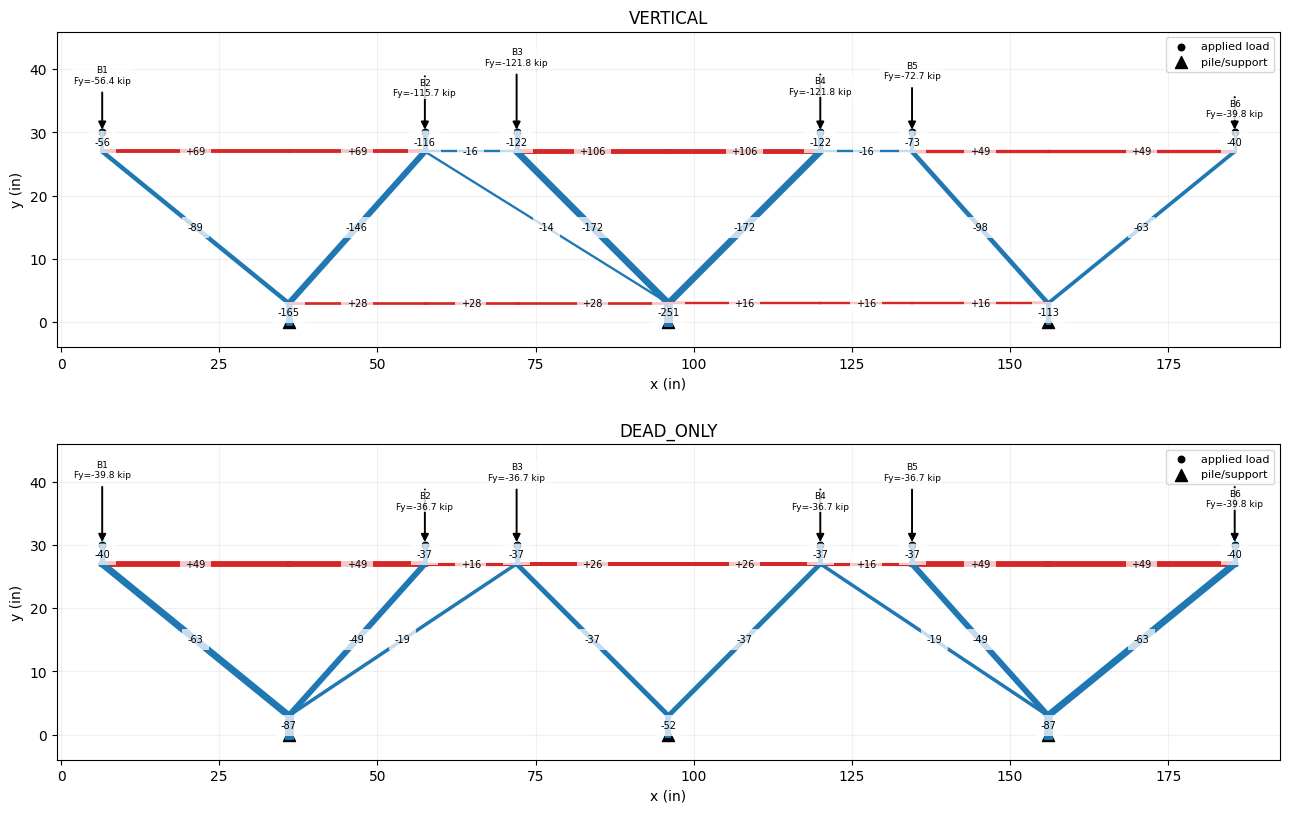

In [7]:
fig, axes = plt.subplots(len(results), 1, figsize=(13, 4.2 * len(results)), squeeze=False)
for ax, (name, result) in zip(axes[:, 0], results.items()):
    truss = result.truss_model
    scale = max(abs(result.member_forces))
    for (i, j), kind, force in zip(truss.members, truss.member_types, result.member_forces):
        color = '#d62728' if kind == 'tie' else '#1f77b4'
        width = 1.4 + 5.0 * abs(force) / scale
        ax.plot(truss.nodes[[i, j], 0], truss.nodes[[i, j], 1], color=color, lw=width)
        midpoint = (truss.nodes[i] + truss.nodes[j]) / 2
        ax.text(*midpoint, f'{force:+.0f}', fontsize=7, ha='center', va='center',
                bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none'})
    loads = combination_loads[name]
    node_min = np.min(truss.nodes, axis=0)
    node_max = np.max(truss.nodes, axis=0)
    node_span = np.maximum(node_max - node_min, 1.0)
    load_vectors = np.asarray([[load.get('Px', 0.0), load.get('Py', 0.0)] for load in loads], dtype=float)
    load_magnitudes = np.linalg.norm(load_vectors, axis=1)
    maximum_load = max(float(np.max(load_magnitudes)), 1.0)
    arrow_scale = 0.32 * max(node_span[1], 0.12 * node_span[0])
    load_plot_points = []
    for load_index, (load, vector, magnitude) in enumerate(zip(loads, load_vectors, load_magnitudes)):
        point = np.asarray([load['x'], load['y']], dtype=float)
        if magnitude > 1e-9:
            display_length = arrow_scale * (0.45 + 0.55 * magnitude / maximum_load)
            display_vector = display_length * vector / magnitude
            tail = point - display_vector
            ax.annotate('', xy=point, xytext=tail,
                        arrowprops={'arrowstyle': '-|>', 'color': 'black', 'lw': 1.4, 'mutation_scale': 11})
            components = []
            if abs(vector[0]) > 1e-9:
                components.append(f'Fx={vector[0]:+.1f}')
            if abs(vector[1]) > 1e-9:
                components.append(f'Fy={vector[1]:+.1f}')
            label = f"{load['id']}\n{', '.join(components)} kip"
            label_offset = 0.025 * max(node_span[1], 1.0) * (1 if load_index % 2 == 0 else -1)
            ax.text(tail[0], tail[1] + label_offset, label, fontsize=6.5, ha='center',
                    va=('bottom' if label_offset >= 0 else 'top'),
                    bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': 'none', 'pad': 1.0})
            load_plot_points.extend((point, tail))
        else:
            ax.text(point[0], point[1], f"{load['id']}\nzero load", fontsize=6.5, ha='center', va='bottom')
            load_plot_points.append(point)
    ax.scatter([load['x'] for load in loads], [load['y'] for load in loads],
               marker='o', s=22, color='black', label='applied load')
    ax.scatter([pile['x'] for pile in piles], [pile['y'] for pile in piles],
               marker='^', s=75, color='black', label=('pile/support' if run_design_checks else 'frame boundary'))
    plot_points = np.vstack((truss.nodes, np.asarray(load_plot_points))) if load_plot_points else truss.nodes
    plot_min = np.min(plot_points, axis=0)
    plot_max = np.max(plot_points, axis=0)
    plot_span = np.maximum(plot_max - plot_min, 1.0)
    length_unit = project['units']['length']
    ax.set(title=name, xlabel=f'x ({length_unit})', ylabel=f'y ({length_unit})', aspect='equal',
           xlim=(plot_min[0] - 0.04 * plot_span[0], plot_max[0] + 0.04 * plot_span[0]),
           ylim=(plot_min[1] - 0.10 * plot_span[1], plot_max[1] + 0.16 * plot_span[1]))
    ax.grid(alpha=0.18)
    ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)

In [8]:
def member_signature(result, member):
    i, j = member
    points = [
        tuple(float(value) for value in np.round(result.truss_model.nodes[index], 6))
        for index in (i, j)
    ]
    return tuple(sorted(points))

topologies = {
    name: {member_signature(result, member) for member in result.truss_model.members}
    for name, result in results.items()
}
common_members = set.intersection(*topologies.values())
union_members = set.union(*topologies.values())
print(f"Members common to every combination: {len(common_members)}")
print(f"Members appearing in any combination: {len(union_members)}")
if common_members != union_members:
    print('REVIEW REQUIRED: independently optimized combinations produced different topologies.')
else:
    print('All demonstration combinations selected the same topology.')

Members common to every combination: 23
Members appearing in any combination: 32
REVIEW REQUIRED: independently optimized combinations produced different topologies.


## 5. Tie, strut, and nodal-zone checks

The calculations use the supplied AASHTO strut equation, AREMA 2025 Article 2.30.2b resistance factors, Article 2.42 face-specific nodal factors, and the supplied AREMA reinforcement development/detailing provisions. Consequential project defaults remain visible above.

In [9]:
if run_design_checks:
    # Provisional design inputs - review and replace when AREMA criteria are supplied.
    preliminary_design = {
        'phi_tie': code_profile['phi_tie'],
        'phi_concrete': code_profile['phi_concrete'],
        'strut_eps_1': 0.002,
        'strut_fcu_cap_factor': 0.85,
        'node_stress_factors': arema_2025_nodal_stress_factors(materials['fc_ksi']),
        'nodal_confinement_factor': 1.0,
        'load_nodal_back_depth': 2.0 * (cap['depth'] - cap['top_tie_y']),
        'support_nodal_back_depth': 2.0 * cap['bottom_tie_y'],
        'crack_control_bar_size': 5,
        'crack_control_legs': 2,
        'crack_control_ratio': 0.003,
        'crack_control_max_spacing': 12.0,
        'crack_control_spacing_increment': 0.5,
        'maximum_aggregate_size': detailing['maximum_aggregate_size'],
        'maximum_longitudinal_bar_size': detailing['maximum_longitudinal_bar_size'],
        'crack_control_effective_depth': max(
            cap['top_tie_y'], cap['depth'] - cap['bottom_tie_y'],
        ),
        'lightweight_concrete': detailing['lightweight_concrete'],
        'epoxy_coated_reinforcement': detailing['epoxy_coated_reinforcement'],
        'credit_excess_reinforcement_for_development': detailing['credit_excess_reinforcement_for_development'],
    }
    load_point_ids = sorted({load['id'] for loads in load_components.values() for load in loads})
    load_bearing_widths = dict(load_face_widths)
    pile_bearing_widths = {pile['id']: pile['face_width'] for pile in piles}
    print(code_profile['name'])
    print(code_profile['resistance_factor_status'])
    print(f"Detailing defaults: cover={detailing['clear_cover']} in, aggregate={detailing['maximum_aggregate_size']} in, bars #{detailing['minimum_longitudinal_bar_size']}-#{detailing['maximum_longitudinal_bar_size']}")
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


AREMA 2025 Chapter 8 Articles 2.30.2b and 2.42 + supplied reinforcement sections
VERIFIED - AREMA 2025 Article 2.30.2b
Detailing defaults: cover=2.0 in, aggregate=0.75 in, bars #5-#5


In [10]:
if run_design_checks:
    force_envelope = {}
    for combination, result in results.items():
        for member, force in zip(result.truss_model.members, result.member_forces):
            signature = member_signature(result, member)
            record = force_envelope.setdefault(signature, {
                'max_tension': 0.0, 'max_compression': 0.0,
                'tension_combination': None, 'compression_combination': None,
            })
            if force > record['max_tension']:
                record['max_tension'] = float(force)
                record['tension_combination'] = combination
            if force < record['max_compression']:
                record['max_compression'] = float(force)
                record['compression_combination'] = combination
    print(f'Force envelope assembled for {len(force_envelope)} geometric members.')
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


Force envelope assembled for 32 geometric members.


In [11]:
if run_design_checks:
    tie_checks = []
    for member_id, (signature, record) in enumerate(sorted(force_envelope.items())):
        if record['max_tension'] <= 0.0:
            continue
        check = check_tie(
            member_id, record['max_tension'], materials['fy_ksi'],
            phi=preliminary_design['phi_tie'],
        )
        tie_checks.append((signature, record['tension_combination'], check))
    print(f"{'member endpoints (in)':<38} {'combo':<26} {'Tu':>8} {'As req':>9} {'provide':>12} {'D/C':>7}")
    print('-' * 108)
    for signature, combination, check in tie_checks:
        label = f'{signature[0]} to {signature[1]}'
        provided = f"{check.n_bars}-#{check.bar_size}"
        print(f"{label:<38} {combination:<26} {check.force:8.1f} {check.As_required:9.3f} {provided:>12} {check.dc_ratio:7.3f}")
    tie_bar_layouts = []
    for signature, combination, check in tie_checks:
        layout = design_tie_bar_layout(
            check.As_required, cap['width'],
            tie_zone_depth=min(
                preliminary_design['load_nodal_back_depth'],
                preliminary_design['support_nodal_back_depth'],
            ),
            enclosure_bar_size=preliminary_design['crack_control_bar_size'],
            clear_cover=detailing['clear_cover'],
            maximum_aggregate_size=preliminary_design['maximum_aggregate_size'],
            allowed_bar_sizes=tuple(range(detailing['minimum_longitudinal_bar_size'], preliminary_design['maximum_longitudinal_bar_size'] + 1)),
        )
        tie_bar_layouts.append((signature, combination, layout))
    tie_layout_records = tie_bar_layout_records(
        [layout for _, _, layout in tie_bar_layouts]
    )
    for record, (signature, combination, _) in zip(tie_layout_records, tie_bar_layouts):
        record.update({'member_endpoints': signature, 'combination': combination})
    tie_layout_table = records_to_dataframes({'tie_layouts': tie_layout_records})['tie_layouts']
    print(f"{'member endpoints (in)':<38} {'combo':<20} {'As req':>8} {'layout':>15} {'clear':>8} {'status':>7}")
    print('-' * 105)
    for signature, combination, layout in tie_bar_layouts:
        label = f'{signature[0]} to {signature[1]}'
        arrangement = f"{layout.bar_count}-#{layout.bar_size} / {layout.layers} layer"
        print(f"{label:<38} {combination:<20} {layout.as_required:8.3f} {arrangement:>15} {layout.transverse_clear_spacing:8.2f} {layout.status:>7}")
    layer_demands = {}
    for signature, combination, check in tie_checks:
        y0, y1 = signature[0][1], signature[1][1]
        if not np.isclose(y0, y1):
            continue
        layer = 'top longitudinal tie' if np.isclose(y0, cap['top_tie_y']) else 'bottom longitudinal tie'
        governing = layer_demands.get(layer)
        if governing is None or check.As_required > governing['As_required']:
            layer_demands[layer] = {
                'As_required': check.As_required, 'combination': combination,
                'member_endpoints': signature,
            }
    common_tie_layouts = {}
    print('\nCommon longitudinal layer schedule:')
    for layer, demand in layer_demands.items():
        short_name = 'top' if layer.startswith('top') else 'bottom'
        provided = (provided_reinforcement or {}).get(short_name)
        layout_options = {
            'tie_zone_depth': min(preliminary_design['load_nodal_back_depth'], preliminary_design['support_nodal_back_depth']),
            'enclosure_bar_size': preliminary_design['crack_control_bar_size'],
            'clear_cover': detailing['clear_cover'],
            'maximum_aggregate_size': preliminary_design['maximum_aggregate_size'],
        }
        if provided is None:
            layout = design_tie_bar_layout(
                demand['As_required'], cap['width'], **layout_options,
                allowed_bar_sizes=tuple(range(detailing['minimum_longitudinal_bar_size'], preliminary_design['maximum_longitudinal_bar_size'] + 1)),
            )
        else:
            layout = check_provided_tie_bar_layout(
                demand['As_required'], cap['width'], **provided, **layout_options,
            )
        common_tie_layouts[layer] = layout
        print(f"  {layer}: {layout.bar_count}-#{layout.bar_size} in {layout.layers} layer(s); As={layout.as_provided:.2f} in^2; transverse spacing={layout.transverse_center_spacing:.2f} in")
    tie_layer_positions = {layer: set() for layer in common_tie_layouts}
    for signature, _, _ in tie_checks:
        y0, y1 = signature[0][1], signature[1][1]
        if not np.isclose(y0, y1):
            continue
        layer = 'top longitudinal tie' if np.isclose(y0, cap['top_tie_y']) else 'bottom longitudinal tie'
        tie_layer_positions[layer].update((signature[0][0], signature[1][0]))
    provided_grid = (provided_reinforcement or {}).get('crack_control')
    if provided_grid is None:
        crack_control_grid = design_orthogonal_crack_control_grid(
            cap['width'], preliminary_design['crack_control_effective_depth'],
            bar_size=preliminary_design['crack_control_bar_size'],
            legs=preliminary_design['crack_control_legs'],
            required_ratio=preliminary_design['crack_control_ratio'],
            absolute_spacing_limit=preliminary_design['crack_control_max_spacing'],
            spacing_increment=preliminary_design['crack_control_spacing_increment'],
        )
    else:
        crack_control_grid = check_provided_crack_control_grid(
            cap['width'], preliminary_design['crack_control_effective_depth'],
            provided_grid, required_ratio=preliminary_design['crack_control_ratio'],
            absolute_spacing_limit=preliminary_design['crack_control_max_spacing'],
        )
        if any(item.bar_size is None or item.legs is None for item in crack_control_grid):
            raise ValueError('Production crack-control input requires bar_size, legs, and spacing in both directions')
    development_grid = crack_control_grid[0]
    tie_development_calculations = {}
    tie_hook_alternatives = {}
    tie_anchorage_geometries = []
    for layer, layout in common_tie_layouts.items():
        center_cover = layout.clear_cover + REBAR_TABLE[layout.enclosure_bar_size]['db'] + 0.5 * REBAR_TABLE[layout.bar_size]['db']
        development = calculate_tension_development_length(
            layout.bar_size, materials['fy_ksi'], materials['fc_ksi'],
            top_bar=layer.startswith('top'),
            lightweight=preliminary_design['lightweight_concrete'],
            epoxy_coated=preliminary_design['epoxy_coated_reinforcement'],
            cover=center_cover, clear_spacing=layout.transverse_clear_spacing,
            transverse_reinforcement_area=development_grid.steel_area_per_spacing,
            transverse_spacing=development_grid.selected_spacing,
            bars_in_splitting_plane=layout.bar_count,
            as_required=layout.as_required, as_provided=layout.as_provided,
            apply_excess_reinforcement_factor=preliminary_design['credit_excess_reinforcement_for_development'],
        )
        tie_development_calculations[layer] = development
        hook = calculate_standard_hook_development(
            layout.bar_size, materials['fy_ksi'], materials['fc_ksi'],
            hook_angle=90,
            epoxy_coated=preliminary_design['epoxy_coated_reinforcement'],
            adequate_cover=(layout.clear_cover + REBAR_TABLE[layout.enclosure_bar_size]['db'] >= 2.5),
            lightweight=preliminary_design['lightweight_concrete'],
            as_required=layout.as_required, as_provided=layout.as_provided,
            apply_excess_reinforcement_factor=preliminary_design['credit_excess_reinforcement_for_development'],
        )
        hook_fits_transversely = hook.transverse_projection <= cap['depth'] - 2.0 * center_cover
        tie_hook_alternatives[layer] = (hook, hook_fits_transversely)
        preliminary_geometry = calculate_tie_end_anchorage_geometry(
            layer, tie_layer_positions[layer], 0.0, cap['length'], layout.bar_size,
            enclosure_bar_size=preliminary_design['crack_control_bar_size'],
            clear_cover=detailing['clear_cover'],
            required_development_lengths={'left': development.required_length, 'right': development.required_length},
        )
        required_by_end = {item.end: development.required_length for item in preliminary_geometry}
        type_by_end = {item.end: 'straight' for item in preliminary_geometry}
        for item in preliminary_geometry:
            if item.status == 'NG' and detailing['allow_standard_hooks'] and hook_fits_transversely and item.available_length >= hook.required_length:
                required_by_end[item.end] = hook.required_length
                type_by_end[item.end] = 'standard 90-degree hook'
        tie_anchorage_geometries.extend(calculate_tie_end_anchorage_geometry(
            layer, tie_layer_positions[layer], 0.0, cap['length'], layout.bar_size,
            enclosure_bar_size=preliminary_design['crack_control_bar_size'],
            clear_cover=detailing['clear_cover'],
            required_development_lengths=required_by_end, anchorage_type=type_by_end,
        ))
    tie_development_table = records_to_dataframes({
        'tie_development': tension_development_records(tie_development_calculations.values()),
    })['tie_development']
    tie_hook_table = records_to_dataframes({
        'tie_hooks': standard_hook_records([item[0] for item in tie_hook_alternatives.values()]),
    })['tie_hooks']
    tie_anchorage_table = records_to_dataframes({
        'tie_anchorage': tie_anchorage_records(tie_anchorage_geometries),
    })['tie_anchorage']
    print('\nAREMA 2.14 straight-bar development:')
    for layer, item in tie_development_calculations.items():
        print(f'  {layer}: basic={item.basic_length:.2f} in, confinement={item.confinement_factor:.3f}, required={item.required_length:.2f} in')
    print('\nAREMA 2.17 standard 90-degree-hook alternatives:')
    for layer, (item, fits) in tie_hook_alternatives.items():
        print(f'  {layer}: required={item.required_length:.2f} in, transverse projection={item.transverse_projection:.2f} in, fits={fits}')
    print('\nAvailable end anchorage geometry:')
    for item in tie_anchorage_geometries:
        print(f'  {item.layer}, {item.end}: {item.available_length:.2f} in available, {item.anchorage_type}, required={item.required_development_length:.2f} in - {item.status}')
    print(f"Layouts use {detailing['clear_cover']} in cover, a #{preliminary_design['crack_control_bar_size']} enclosure, aggregate-dependent clear spacing, and user-visible preferred bar limits.")
    excess_credit = 'enabled' if detailing['credit_excess_reinforcement_for_development'] else 'disabled'
    print(f"Development requirements use AREMA 2.14/2.17; lightweight={detailing['lightweight_concrete']}, epoxy={detailing['epoxy_coated_reinforcement']}, and excess-steel reduction={excess_credit}.")
    print('STM longitudinal ties are scheduled as continuous bars without lap splices per AREMA 2.22.3e; headed/mechanical anchorages are excluded by project direction.')
    print('End anchorage shown here is preliminary; the external-node cell replaces midpoint boundaries with extended-strut intersections.')
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


member endpoints (in)                  combo                            Tu    As req      provide     D/C
------------------------------------------------------------------------------------------------------------
(6.5, 27.0) to (36.0, 27.0)            VERTICAL                       69.3     1.283         2-#8   0.812
(36.0, 3.0) to (57.5, 3.0)             VERTICAL                       27.9     0.516         2-#5   0.833
(36.0, 27.0) to (57.5, 27.0)           VERTICAL                       69.3     1.283         2-#8   0.812
(57.5, 3.0) to (72.0, 3.0)             VERTICAL                       27.9     0.516         2-#5   0.833
(57.5, 27.0) to (72.0, 27.0)           DEAD_ONLY                      16.0     0.297         2-#5   0.478
(72.0, 3.0) to (96.0, 3.0)             VERTICAL                       27.9     0.516         2-#5   0.833
(72.0, 27.0) to (96.0, 27.0)           VERTICAL                      105.5     1.955         2-#9   0.977
(96.0, 3.0) to (120.0, 3.0)            VERT

In [12]:
if run_design_checks:
    print('Strut capacity checks are deferred until both nodal-interface widths are calculated below.')
    print('No assumed default strut width is used in the production workflow.')
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


Strut capacity checks are deferred until both nodal-interface widths are calculated below.
No assumed default strut width is used in the production workflow.


In [13]:
if run_design_checks:
    nodal_group_geometries = {}
    nodal_face_checks = {}
    for combination, result in results.items():
        combination_geometries = []
        combination_checks = []
        for face in result.truss_model.external_faces:
            if face.kind == 'bearing_plate':
                source_id = combination_loads[combination][face.source_index]['id']
                location = f'load {source_id}'
                back_depth = preliminary_design['load_nodal_back_depth']
            else:
                source_id = piles[face.source_index]['id']
                location = f'{face.kind.replace("_head", "")} {source_id}'
                back_depth = preliminary_design['support_nodal_back_depth']
            if detailing.get('allow_automatic_external_node_subdivision', False):
                geometries = construct_memberwise_external_nodal_zones(
                    face, result.truss_model, result.member_forces, back_depth,
                    label=location,
                )
            else:
                geometries = (construct_single_strut_external_nodal_zone(
                    face, result.truss_model, result.member_forces, back_depth,
                    label=location,
                ),)
            for geometry in geometries:
                checks = check_subdivided_nodal_zone_faces(
                    geometry, cap['width'], materials['fc_ksi'],
                    phi=preliminary_design['phi_concrete'],
                    stress_factors=preliminary_design['node_stress_factors'],
                    confinement_factor=preliminary_design['nodal_confinement_factor'],
                )
                combination_geometries.append(geometry)
                combination_checks.extend(checks)
        nodal_group_geometries[combination] = tuple(combination_geometries)
        nodal_face_checks[combination] = tuple(combination_checks)

    nodal_geometry_tables = {
        combination: records_to_dataframes(
            nodal_geometry_records(group_geometries=geometries)
        )['nodal_zone_groups']
        for combination, geometries in nodal_group_geometries.items()
    }
    nodal_check_tables = {
        combination: records_to_dataframes(
            design_check_records(nodal_face_checks=checks)
        )['nodal_face_checks']
        for combination, checks in nodal_face_checks.items()
    }
    print(f"{'combination':<24} {'location':<12} {'face':<17} {'demand':>9} {'width':>8} {'phi Pn':>10} {'D/C':>7} {'status':>7}")
    print('-' * 104)
    for combination, checks in nodal_face_checks.items():
        for check in checks:
            print(f"{combination:<24} {check.group_label:<12} {check.face_type:<17} {check.demand:9.1f} {check.face_width:8.2f} {check.capacity:10.1f} {check.dc_ratio:7.3f} {check.status:>7}")
    print('External nodal envelopes and bearing, back, and strut-interface faces are constructed and screened.')
    if detailing.get('allow_automatic_external_node_subdivision', False):
        print('Multi-strut external faces use memberwise force-proportioned tributaries; review the printed nodal groups and geometry.')
    else:
        print('Any external node with multiple compression struts stops and requires an explicit reviewed plan or opt-in subdivision.')

    # Replace midpoint anchorage proxies with the governing extended-strut/tie intersections.
    extended_critical_sections = {}
    extended_critical_sources = {}
    for layer in common_tie_layouts:
        tie_y = cap['top_tie_y'] if layer.startswith('top') else cap['bottom_tie_y']
        intersections = {'left': [], 'right': []}
        for combination, geometries in nodal_group_geometries.items():
            face_kind = 'bearing_plate' if layer.startswith('top') else 'pile_head'
            candidates = [item for item in geometries if item.tributary.parent_kind == face_kind]
            if not candidates:
                continue
            for end, item in (('left', min(candidates, key=lambda value: value.tributary.center[0])), ('right', max(candidates, key=lambda value: value.tributary.center[0]))):
                coordinate = extended_strut_tie_critical_section(item, tie_y, end)
                intersections[end].append((coordinate, combination, item.label))
        if not all(intersections.values()):
            raise RuntimeError(f'No external extended-strut boundary found for {layer}')
        left = min(intersections['left'], key=lambda value: value[0])
        right = max(intersections['right'], key=lambda value: value[0])
        extended_critical_sections[layer] = {'left': left[0], 'right': right[0]}
        extended_critical_sources[layer] = {
            'left': f'extended strut boundary: {left[1]} / {left[2]}',
            'right': f'extended strut boundary: {right[1]} / {right[2]}',
        }
    tie_anchorage_geometries = []
    for layer, layout in common_tie_layouts.items():
        development = tie_development_calculations[layer]
        hook, hook_fits = tie_hook_alternatives[layer]
        straight = calculate_tie_end_anchorage_geometry(
            layer, tie_layer_positions[layer], 0.0, cap['length'], layout.bar_size,
            enclosure_bar_size=preliminary_design['crack_control_bar_size'],
            clear_cover=detailing['clear_cover'],
            required_development_lengths={'left': development.required_length, 'right': development.required_length},
            critical_section_coordinates=extended_critical_sections[layer],
            critical_section_basis=extended_critical_sources[layer],
        )
        required_by_end = {item.end: development.required_length for item in straight}
        type_by_end = {item.end: 'straight' for item in straight}
        for item in straight:
            if item.status == 'NG' and detailing['allow_standard_hooks'] and hook_fits and item.available_length >= hook.required_length:
                required_by_end[item.end] = hook.required_length
                type_by_end[item.end] = 'standard 90-degree hook'
        tie_anchorage_geometries.extend(calculate_tie_end_anchorage_geometry(
            layer, tie_layer_positions[layer], 0.0, cap['length'], layout.bar_size,
            enclosure_bar_size=preliminary_design['crack_control_bar_size'],
            clear_cover=detailing['clear_cover'],
            required_development_lengths=required_by_end, anchorage_type=type_by_end,
            critical_section_coordinates=extended_critical_sections[layer],
            critical_section_basis=extended_critical_sources[layer],
        ))
    tie_anchorage_table = records_to_dataframes({'tie_anchorage': tie_anchorage_records(tie_anchorage_geometries)})['tie_anchorage']
    cage_reviews = []
    for layer, layout in common_tie_layouts.items():
        layer_anchorage = [item for item in tie_anchorage_geometries if item.layer == layer]
        selected_hooks = [tie_hook_alternatives[layer][0].transverse_projection for item in layer_anchorage if item.anchorage_type.startswith('standard')]
        cage_reviews.append(check_reinforcement_cage_congestion(
            layer, layout, member_depth=cap['depth'],
            crack_control_bar_size=development_grid.bar_size,
            crack_control_spacing=development_grid.selected_spacing,
            maximum_aggregate_size=preliminary_design['maximum_aggregate_size'],
            hook_projections=selected_hooks,
            anchorage_statuses=[item.status for item in layer_anchorage],
        ))
    cage_review_table = records_to_dataframes({'cage_reviews': reinforcement_cage_review_records(cage_reviews)})['cage_reviews']
    print('\nFinal extended-strut anchorage and cage review:')
    for item in tie_anchorage_geometries:
        print(f'  {item.layer}, {item.end}: critical x={item.critical_section_coordinate:.2f} in, available={item.available_length:.2f} in, {item.anchorage_type}, required={item.required_development_length:.2f} in - {item.status}')
    for item in cage_reviews:
        print(f'  {item.layer}: longitudinal clear {item.provided_transverse_clear_spacing:.2f}/{item.required_transverse_clear_spacing:.2f} in; crack-grid clear {item.provided_crack_control_clear_spacing:.2f}/{item.required_crack_control_clear_spacing:.2f} in; cage {item.status}')
    print('Maximum aggregate size and cover are visible inputs. Section-level spacing, anchorage, and hook-fit checks are complete; final bar positioning is outside this 2D analysis tool.')
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


combination              location     face                 demand    width     phi Pn     D/C  status
--------------------------------------------------------------------------------------------------------
VERTICAL                 load B1 / strut 10 bearing                56.4    12.00     1234.8   0.046      OK
VERTICAL                 load B1 / strut 10 back                   69.3     6.00      617.4   0.112      OK
VERTICAL                 load B1 / strut 10 strut_interface        89.3    12.23     1078.4   0.083      OK
VERTICAL                 load B2 / strut 13 bearing               108.5    11.25     1157.3   0.094      OK
VERTICAL                 load B2 / strut 13 back                   97.2     6.00      617.4   0.157      OK
VERTICAL                 load B2 / strut 13 strut_interface       145.6    12.41     1094.2   0.133      OK
VERTICAL                 load B2 / strut 14 bearing                 7.3     0.75       77.5   0.094      OK
VERTICAL                 load B2 / st

In [14]:
if run_design_checks:
    interior_nodal_group_geometries = {}
    interior_nodal_geometry_failures = {}
    for combination, result in results.items():
        geometries = []
        failures = []
        external_node_ids = {face.node_id for face in result.truss_model.external_faces}
        for node_id, point in enumerate(result.truss_model.nodes):
            if node_id in external_node_ids:
                continue
            connected = [
                result.member_forces[member_id]
                for member_id, member in enumerate(result.truss_model.members)
                if node_id in member
            ]
            if not any(force < -1e-9 for force in connected):
                continue
            if np.isclose(point[1], cap['top_tie_y']):
                back_depth = preliminary_design['load_nodal_back_depth']
            elif np.isclose(point[1], cap['bottom_tie_y']):
                back_depth = preliminary_design['support_nodal_back_depth']
            else:
                failures.append((node_id, 'node is outside a defined tie layer'))
                continue
            try:
                geometries.extend(construct_continuous_tie_nodal_zone(
                    result.truss_model, result.member_forces, node_id, back_depth,
                    assume_continuous_reinforcement=True,
                    split_opposite_sides=True,
                    tie_axis=(1.0, 0.0),
                    tie_boundary_points=((0.0, point[1]), (cap['length'], point[1])),
                ))
            except ValueError as exc:
                failures.append((node_id, str(exc)))
        interior_nodal_group_geometries[combination] = tuple(geometries)
        interior_nodal_geometry_failures[combination] = tuple(failures)

    interior_nodal_geometry_tables = {
        combination: records_to_dataframes(
            nodal_geometry_records(group_geometries=geometries)
        )['nodal_zone_groups']
        for combination, geometries in interior_nodal_group_geometries.items()
    }
    interior_nodal_face_checks = {}
    for combination, geometries in interior_nodal_group_geometries.items():
        interior_nodal_face_checks[combination] = tuple(
            check for geometry in geometries
            for check in check_interior_nodal_zone_faces(
                geometry, cap['width'], materials['fc_ksi'],
                phi=preliminary_design['phi_concrete'],
                stress_factors=preliminary_design['node_stress_factors'],
                confinement_factor=1.0,
            )
        )
    for combination in results:
        print(f'{combination}: constructed {len(interior_nodal_group_geometries[combination])} interior strut interfaces')
        checks = interior_nodal_face_checks[combination]
        print(f'  capacity faces: {len(checks)} checked; maximum D/C={max((item.dc_ratio for item in checks), default=0.0):.3f}; status={"OK" if all(item.status == "OK" for item in checks) else "NG"}')
        for node_id, reason in interior_nodal_geometry_failures[combination]:
            print(f'  unresolved node {node_id}: {reason}')
    print('Interior policy: continuous horizontal ties, midpoint tributaries, separated opposite strut sides, CCT/CCC stress factors, and no confinement or fan-spreading enhancement.')
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


VERTICAL: constructed 0 interior strut interfaces
  capacity faces: 0 checked; maximum D/C=0.000; status=OK
DEAD_ONLY: constructed 0 interior strut interfaces
  capacity faces: 0 checked; maximum D/C=0.000; status=OK
Interior policy: continuous horizontal ties, midpoint tributaries, separated opposite strut sides, CCT/CCC stress factors, and no confinement or fan-spreading enhancement.


In [15]:
if run_design_checks:
    strut_width_profiles = {}
    strut_width_tables = {}
    geometry_strut_checks = {}
    for combination, result in results.items():
        profiles = calculate_strut_width_profiles(
            result.truss_model, result.member_forces,
            nodal_group_geometries[combination]
            + interior_nodal_group_geometries[combination],
        )
        strut_width_profiles[combination] = profiles
        strut_width_tables[combination] = records_to_dataframes({
            'strut_widths': strut_width_records(profiles),
        })['strut_widths']
        geometry_strut_checks[combination] = tuple(
            check_strut(
                profile.member_id, result.member_forces[profile.member_id],
                profile.controlling_width, cap['width'], materials['fc_ksi'],
                eps_1=preliminary_design['strut_eps_1'],
                phi=preliminary_design['phi_concrete'],
                fcu_cap_factor=preliminary_design['strut_fcu_cap_factor'],
            )
            for profile in profiles if profile.status == 'complete'
        )

    print(f"{'combination':<24} {'member':>7} {'end i':>9} {'end j':>9} {'control':>9} {'profile':>11} {'status':>9}")
    print('-' * 86)
    for combination, profiles in strut_width_profiles.items():
        for profile in profiles:
            wi = '-' if profile.width_i is None else f'{profile.width_i:.2f}'
            wj = '-' if profile.width_j is None else f'{profile.width_j:.2f}'
            wc = '-' if profile.controlling_width is None else f'{profile.controlling_width:.2f}'
            print(f"{combination:<24} {profile.member_id:7d} {wi:>9} {wj:>9} {wc:>9} {profile.profile_type:>11} {profile.status:>9}")
    print('Only complete two-ended profiles are used for geometry-derived strut capacity checks.')
    print('Partial or missing profiles require construction of the unresolved interior nodal interface.')
    for combination, checks in geometry_strut_checks.items():
        max_dc = max((check.dc_ratio for check in checks), default=float('nan'))
        print(f'{combination}: {len(checks)} geometry-width strut checks; maximum D/C = {max_dc:.3f}')
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


combination               member     end i     end j   control     profile    status
--------------------------------------------------------------------------------------
VERTICAL                      10     12.23      8.60      8.60     tapered  complete
VERTICAL                      11      6.00      6.00      6.00   prismatic  complete
VERTICAL                      13     12.41     13.05     12.41     tapered  complete
VERTICAL                      14      5.29      5.00      5.00     tapered  complete
VERTICAL                      16     12.73     10.56     10.56     tapered  complete
VERTICAL                      17      6.00      6.00      6.00   prismatic  complete
VERTICAL                      19     12.73     10.57     10.57     tapered  complete
VERTICAL                      21     12.94     12.89     12.89     tapered  complete
VERTICAL                      23     12.23      8.75      8.75     tapered  complete
DEAD_ONLY                     10     12.23     10.03     10.03 

In [16]:
if run_design_checks:
    # Optional reviewed field evidence. Do not label bottle/fan behavior from unequal end widths alone.
    strut_shape_evidence = {
        combination: {'midspan_widths': {}, 'fan_member_ids': ()}
        for combination in results
    }
    strut_shape_classifications = {}
    strut_shape_tables = {}
    conservative_strut_designs = {}
    conservative_strut_design_tables = {}
    for combination, profiles in strut_width_profiles.items():
        evidence = strut_shape_evidence[combination]
        classifications = classify_strut_shapes(
            profiles, midspan_widths=evidence['midspan_widths'],
            fan_member_ids=evidence['fan_member_ids'],
        )
        strut_shape_classifications[combination] = classifications
        designs = apply_conservative_strut_policy(profiles, classifications)
        conservative_strut_designs[combination] = designs
        strut_shape_tables[combination] = records_to_dataframes({
            'strut_shapes': strut_shape_records(classifications),
        })['strut_shapes']
        conservative_strut_design_tables[combination] = records_to_dataframes({
            'conservative_strut_designs': conservative_strut_design_records(designs),
        })['conservative_strut_designs']
        counts = {}
        for item in classifications:
            counts[item.shape] = counts.get(item.shape, 0) + 1
        print(f'{combination}: {counts}')
    print('Simplified policy: minimum end width controls; every non-prismatic strut receives bottle-shaped detailing; no fan credit.')
    crack_control_table = records_to_dataframes({
        'crack_control': crack_control_records(crack_control_grid),
    })['crack_control']
    for grid in crack_control_grid:
        description = (f'{grid.legs}-leg #{grid.bar_size}' if grid.bar_size is not None else f'{grid.steel_area_per_spacing:.2f} in^2')
        print(f"{grid.direction}: {description} at {grid.selected_spacing:.1f} in; rho={grid.provided_ratio:.4f}; {grid.status}")

    calculation_records = pier_cap_analysis_records(
        common_analysis,
        external_nodal_checks=nodal_face_checks,
        interior_nodal_checks=interior_nodal_face_checks,
        strut_checks=geometry_strut_checks,
        tie_checks=[check for _, _, check in tie_checks],
        tie_layouts=common_tie_layouts.values(),
        anchorage=tie_anchorage_geometries, cage_reviews=cage_reviews,
        crack_control=crack_control_grid,
    )
    calculation_metadata = build_calculation_metadata(
        inputs={
            'project': project, 'cap': cap, 'materials': materials,
            'detailing': detailing, 'code_profile': code_profile,
            'piles': piles, 'load_components': load_components,
            'load_combinations': load_combinations,
            'provided_reinforcement': provided_reinforcement,
        },
        results=calculation_records, project_revision=project['revision'],
        repo_root=repo_root,
    )
    calculation_records['report_metadata'] = [calculation_metadata]
    calculation_tables = records_to_dataframes(calculation_records)
    calculation_report = build_pier_cap_calculation_report(
        project=project, cap=cap, materials=materials, detailing=detailing,
        code_profile=code_profile, common_analysis=common_analysis,
        tie_layouts=common_tie_layouts, anchorage=tie_anchorage_geometries,
        cage_reviews=cage_reviews, strut_checks=geometry_strut_checks,
        external_nodal_checks=nodal_face_checks,
        interior_nodal_checks=interior_nodal_face_checks,
        metadata=calculation_metadata,
    )
    html_report = build_pier_cap_html_report(
        project=project, cap=cap, materials=materials, detailing=detailing,
        code_profile=code_profile, common_analysis=common_analysis,
        tie_layouts=common_tie_layouts, anchorage=tie_anchorage_geometries,
        cage_reviews=cage_reviews, strut_checks=geometry_strut_checks,
        external_nodal_checks=nodal_face_checks,
        interior_nodal_checks=interior_nodal_face_checks,
        calculation_records=calculation_records, crack_control=crack_control_grid,
        reinforcement_source=('provided' if any(key in (provided_reinforcement or {}) for key in ('top', 'bottom')) else 'selected'),
        metadata=calculation_metadata,
    )
    display(calculation_tables['model_quality'])
    print(calculation_report)
    if output_options['write_files']:
        output_directory = Path(output_options['directory'])
        export_csv_tables(calculation_records, output_directory / 'csv')
        export_json_tables(calculation_records, output_directory / 'pier_cap_results.json')
        write_calculation_report(calculation_report, output_directory / 'calculation_summary.md')
        write_html_report(html_report, output_directory / 'pier_cap_report.html')
        if output_options['write_excel']:
            export_excel_tables(calculation_records, output_directory / 'pier_cap_results.xlsx')
        print(f'Calculation files written to {output_directory.resolve()}')
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


VERTICAL: {'tapered': 7, 'prismatic': 2}
DEAD_ONLY: {'tapered': 8}
Simplified policy: minimum end width controls; every non-prismatic strut receives bottle-shaped detailing; no fan credit.
vertical: 4-leg #5 at 6.0 in; rho=0.0049; OK
horizontal: 2-leg #5 at 6.0 in; rho=0.0025; NG


,combination,selected_member_count,selected_member_length,force_weighted_load_path,maximum_node_degree,equilibrium_residual
0,VERTICAL,30,579.753153,43324.888125,6,2.309264e-14
1,DEAD_ONLY,25,500.918443,20198.549625,5,7.105427e-15


# DEMONSTRATION - Railroad Pier Cap - Calculation Summary

- Project revision: 0
- Tool / notebook / report versions: 0.1.0 / 1.0.0 / 1.0.0
- Result fingerprint: 7ccf40e1cdd35cbb

## Inputs and visible defaults

- Geometry: 201.0 in long x 30.0 in deep x 42.0 in wide
- Materials: f'c = 5.0 ksi; fy = 60.0 ksi
- Clear cover: 2.0 in
- Maximum aggregate size: 0.75 in
- Code profile: AREMA 2025 Chapter 8 Articles 2.30.2b and 2.42 + supplied reinforcement sections
- Resistance-factor status: VERIFIED - AREMA 2025 Article 2.30.2b

## Analysis model

- Common candidates: 64 generated; 32 retained
- Load combinations: VERTICAL, DEAD_ONLY
- Force reversals: 2 reversal(s), designed for both signs

## Reinforcement

- top longitudinal tie: 8-#8, As = 6.32 in^2, 1 layer(s)
- bottom longitudinal tie: 8-#8, As = 6.32 in^2, 1 layer(s)

### Anchorage

- top longitudinal tie, left: 13.06 in available / 36.07 in required, straight, NG
- top longitudinal tie, right: 22.06 in available / 13.58 in required,

## 6. Analysis status and scope

The analysis checks below are automatic. Project activities outside this two-dimensional STM are identified as scope boundaries, not unresolved analysis failures.

| Gate | Current status | Required development |
|---|---|---|
| Common topology across combinations | Implemented | One pruned candidate structure; all cases re-solved; reversals reported and designed for both signs |
| Non-nodal member crossings | Implemented | Diagonal webs default to compression-only; remaining intersections stop the workflow |
| Applied loads | User supplied | Railroad load generation and selection of applicable combinations are outside scope |
| Tie reinforcement | Implemented | Automatic common schedule, spacing, development, hooks, and section-level compatibility |
| Strut shape/capacity | Implemented conservatively | Minimum end width; bottle detailing for non-prismatic struts; no fan credit |
| Crack-control grid | Implemented | AREMA 0.003 ratios, spacing ceiling, and aggregate spacing |
| External nodal zones | Implemented | Face-specific AREMA 2025 factors; explicit plan required only for a true multi-strut external node |
| Interior nodal zones | Implemented conservatively | Continuous ties, midpoint tributaries, separated sides, no confinement enhancement, all faces checked |
| Foundation response | Outside scope | Reactions may be imported from a compatible foundation/global model |
| Final bar positioning and drawings | Outside scope | The notebook completes section-level checks only |
| AREMA resistance factors | Implemented | Article 2.30.2b: 0.70 compression and 0.90 reinforced-concrete STM tension |

The notebook reports all applied code factors, visible project defaults, governing checks, and scope boundaries in the calculation summary.

## 7. Analysis record

For a project calculation package, retain the completed input cell, governing AREMA references, validation output, topology plots, force envelopes, manual topology decisions, and all future design-check results.